#Step1: Load Important Modules

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
print('All Module Loaded Successfully!')

All Module Loaded Successfully!


In [ ]:
#shift + enter to execute the code.
#warnings: Module to ignore all future warnings.
#os: Module to work with folder or path.
#If module error use this: !pip install seaborn matplotlib numpy pandas

#Step 2: Load Dataset

In [18]:
url='https://gist.githubusercontent.com/nnbphuong/38db511db14542f3ba9ef16e69d3814c/raw/3a77ff9d97c504d3ec3210b12fde7242b8c6ab63/Superstore.csv'
df=pd.read_csv(url)
df.sample(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9340,9341,CA-2015-155264,2015-10-19,2015-10-22,Second Class,RP-19270,Rachel Payne,Corporate,United States,San Francisco,...,94110.0,West,OFF-LA-10002787,Office Supplies,Labels,Avery 480,18.75,5,0.0,9.000
1131,1132,CA-2017-112102,2017-04-12,2017-04-16,Standard Class,BD-11605,Brian Dahlen,Consumer,United States,Springfield,...,22153.0,South,OFF-EN-10002500,Office Supplies,Envelopes,Globe Weis Peel & Seel First Class Envelopes,63.90,5,0.0,28.755


#Step 3: Exploratory Data Analysis

In [ ]:
#shape of dataset
df.shape
#This shows: 9k+ Records and 21 columns

(9994, 21)

In [ ]:
# Size of the dataset
df.size
#This Shows: total element in a dataset

209874

In [ ]:
# To check head: by default it gives 5 records
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136


In [ ]:
#To check tail: by default it gives 5 records
df.tail(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9993,9994,CA-2018-119914,2018-05-04,2018-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.16,2,0.0,72.948


In [ ]:
#To check all column info
#It check non null count: means: how much data is not null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9983 non-null   float64
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
#To check null records count
#If all values are zero which means no null
#Postalcode:11 means 11 rows found null
df.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
#To describe the Dataset
#It gives Numerical datset stats info
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55245.233297,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32038.715955,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
# To check categorical data describe
#Categorical means: textual data info
df.describe(include='object')

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,1236,1334,4,793,793,3,1,531,49,4,1862,3,17,1850
top,CA-2018-100111,2017-09-05,2016-12-16,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,35,5968,37,37,5191,9994,915,2001,3203,19,6026,1523,48


In [ ]:
#To check correlation b/w numerical features
df.corr(numeric_only=True)

#The range of corr: (-1 to 1)
# -1: One feature is going up and other is going down
# +1: Both going up
# 0: No correlation

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.011644,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.011644,1.000000,-0.022346,0.013376,0.057243,-0.028751
Sales,-0.001359,-0.022346,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.013376,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.057243,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.028751,0.479064,0.066253,-0.219487,1.000000


#Part 2

In [13]:
#Different Types of Analysis
# 1. Univariate Analysis: pick any one column and perform EDA.
# 2. Bivariate Analysis: pick any two columns and perform EDA.
# 3.Multivariate Analysis: pick any three or more columns and perform EDA.

In [14]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [20]:
num_cols=df.select_dtypes('number').columns
cat_cols=df.select_dtypes('object').columns

In [27]:
print(num_cols)

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')


In [22]:
print(cat_cols)

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name'],
      dtype='object')


In [23]:
#object to datetime
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])
print('Done')

Done


In [24]:
datetime_cols=df.select_dtypes('datetime').columns
print(datetime_cols)

Index(['Order Date', 'Ship Date'], dtype='object')


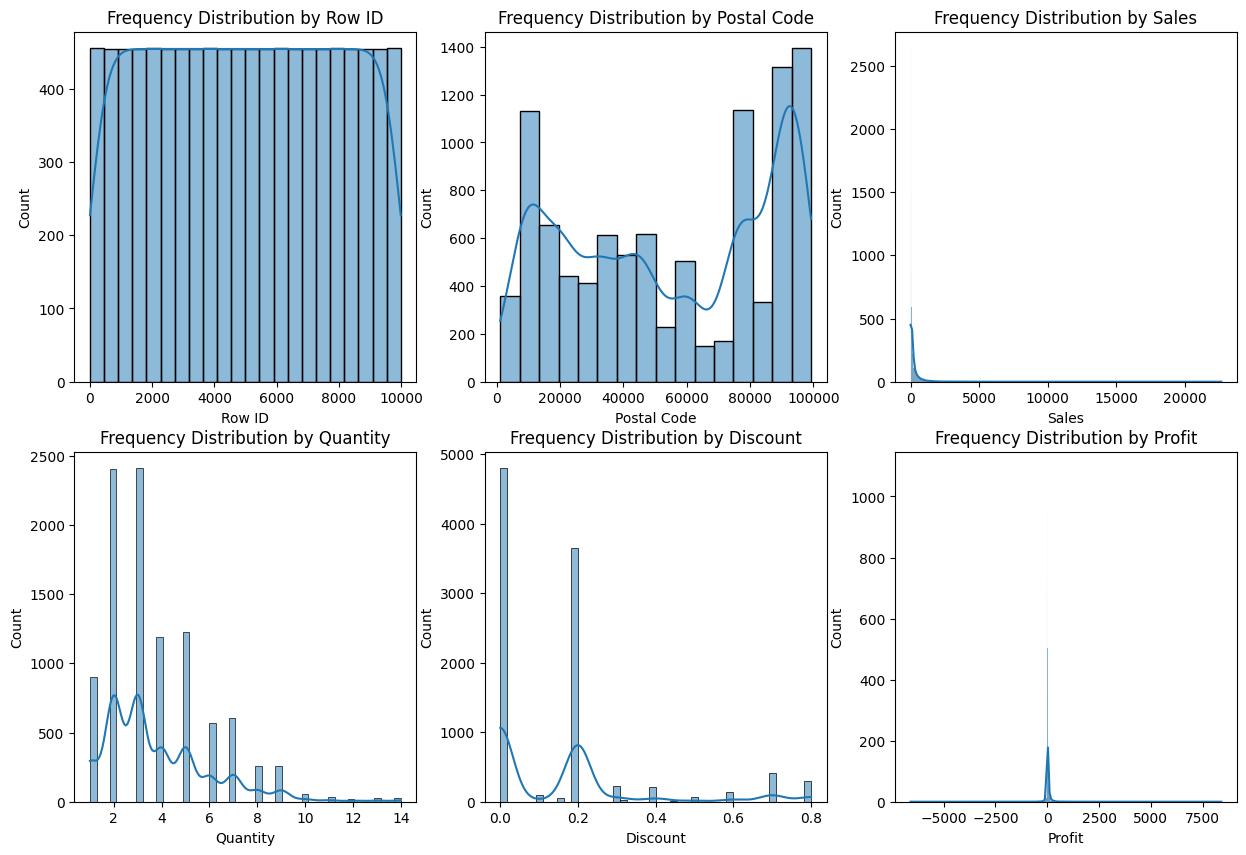

In [29]:
#Univariate Analysis
plt.figure(figsize=(15,10))
for i,j in enumerate(num_cols):
  plt.subplot(2,3, i+1)
  plt.title(f"Frequency Distribution by {j}")
  sns.histplot(data=df, x=j,kde=True)
plt.show()

In [26]:
len(cat_cols)

15

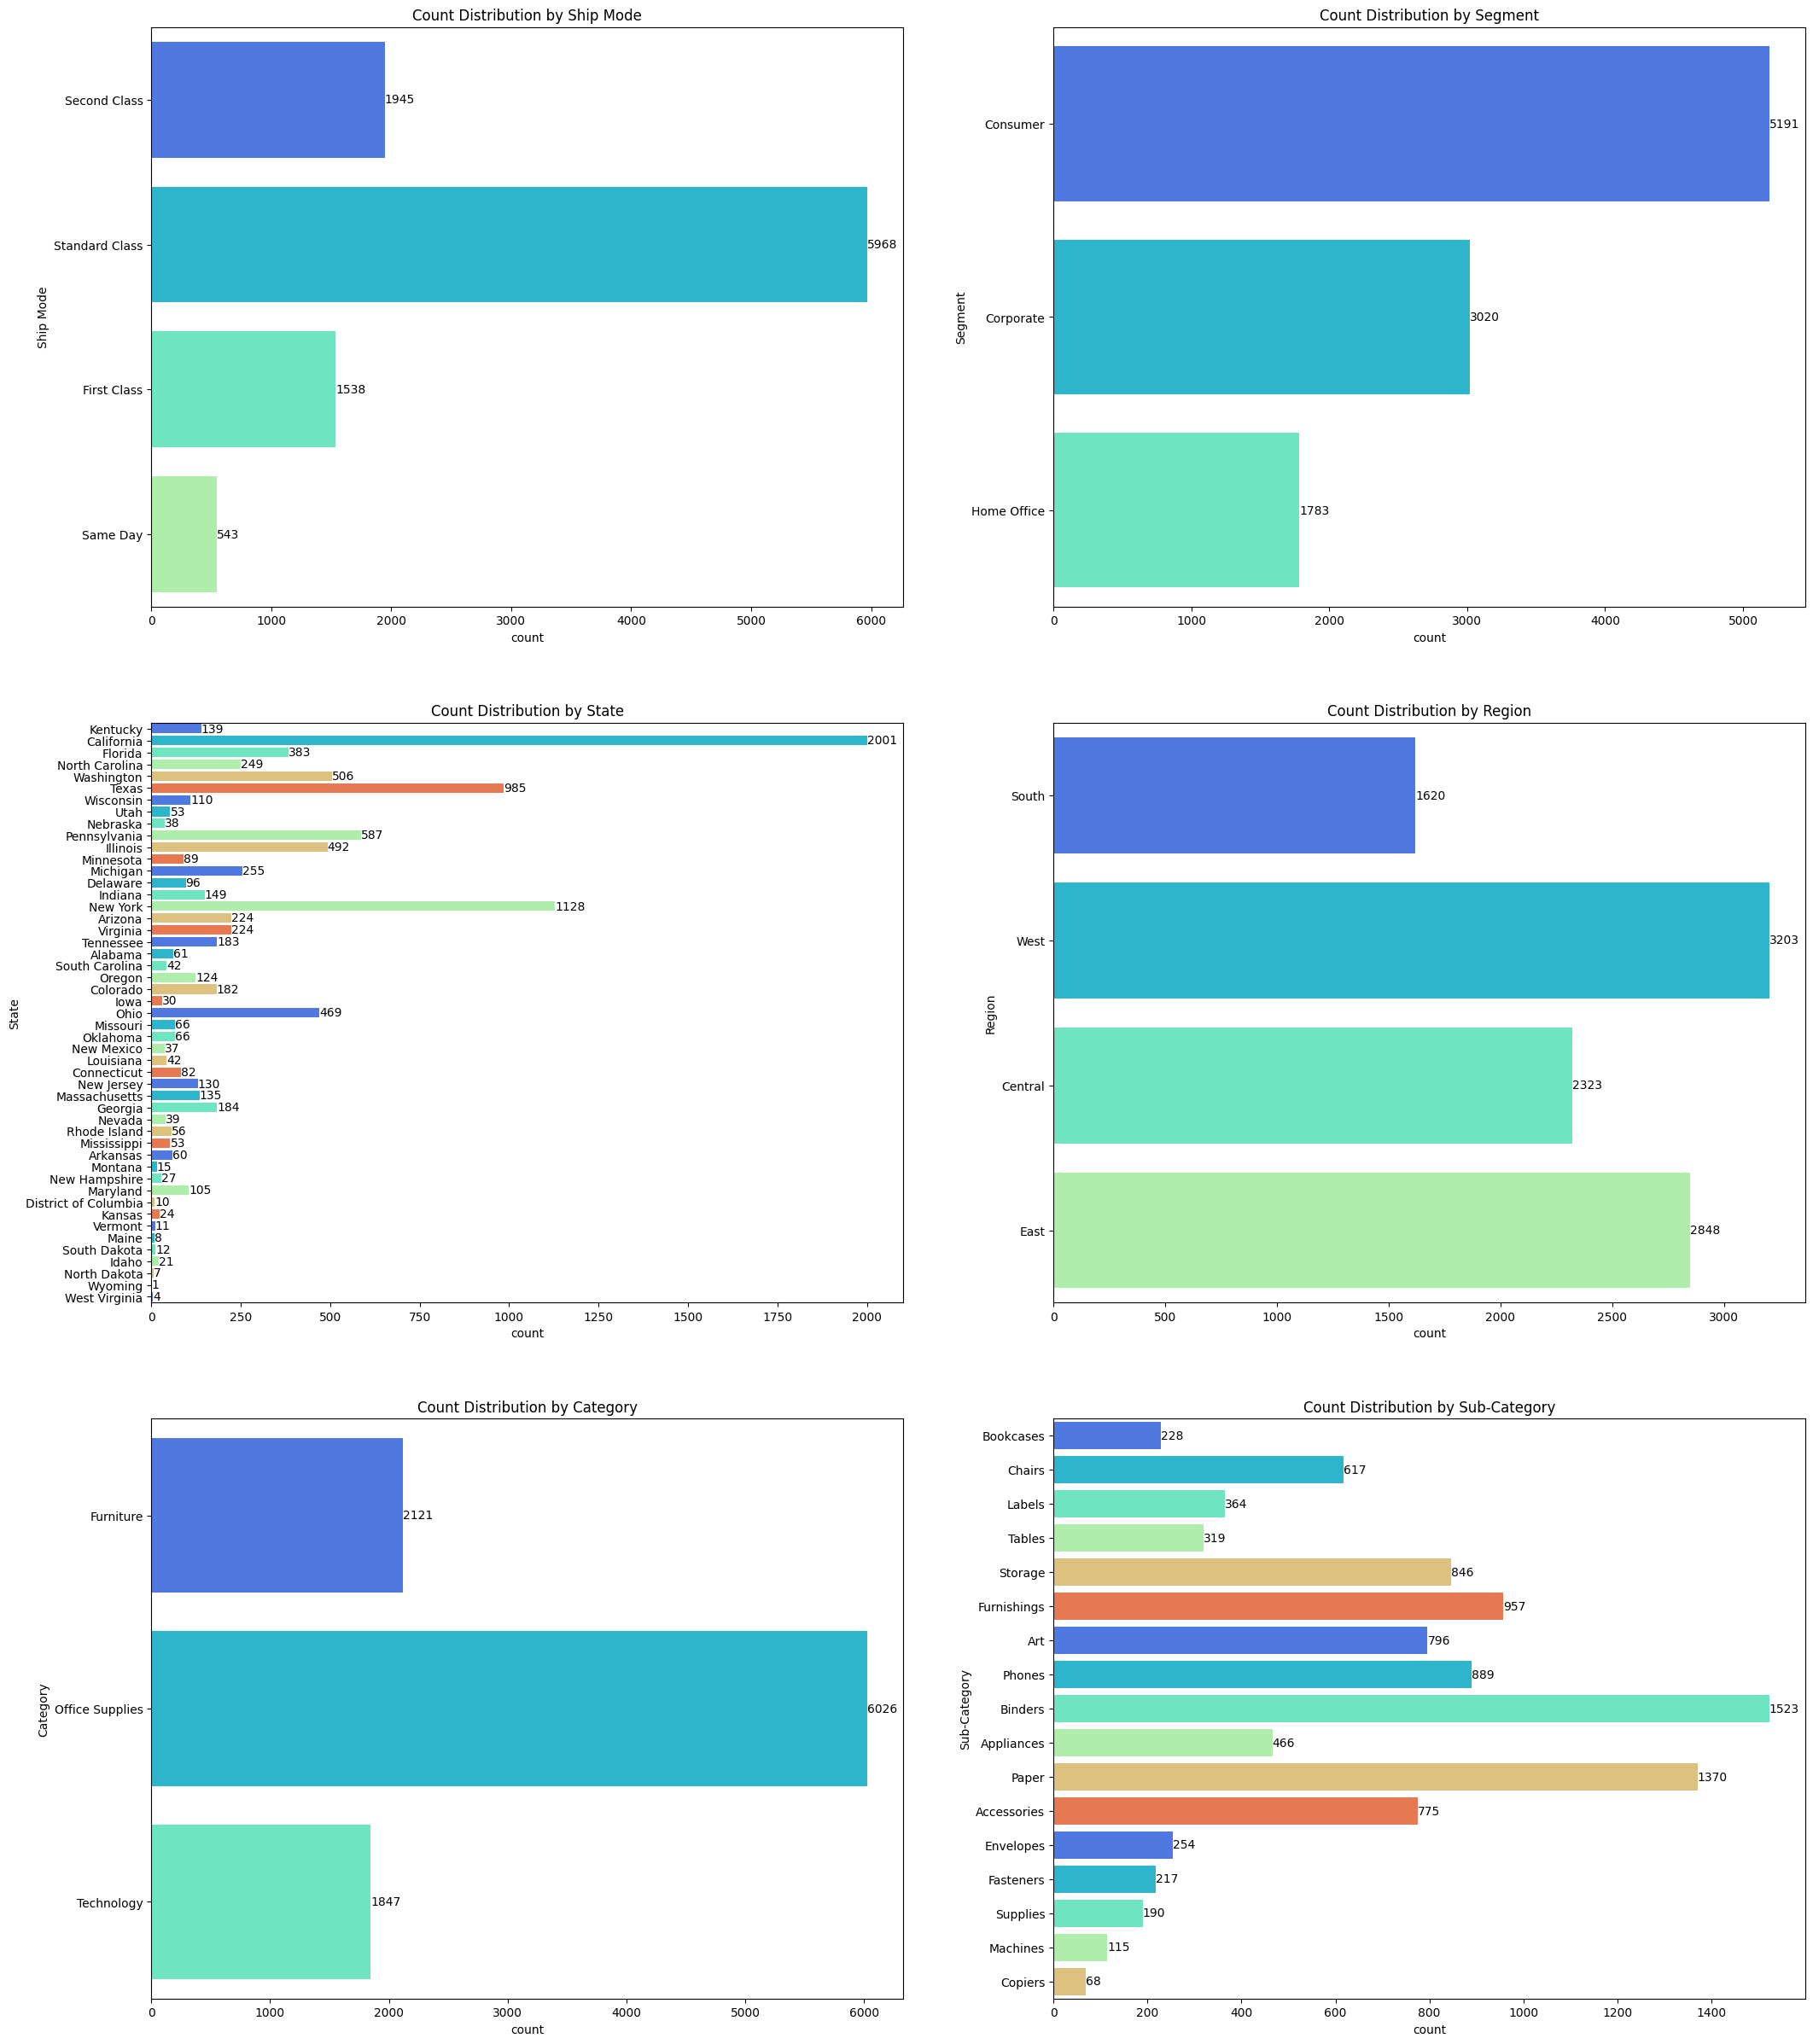

In [ ]:
#Univariate Analysis
new_cat_cols=['Ship Mode','Segment', 'State','Region','Category', 'Sub-Category']

plt.figure(figsize=(25,30))
for i,j in enumerate(new_cat_cols):
  plt.subplot(3,2, i+1)
  plt.title(f"Count Distribution by {j}")
  ax=sns.countplot(data=df, y=j, palette=sns.color_palette('rainbow'), orient= 'v')
  for value in ax.containers:
    plt.bar_label(value)
  plt.yticks(fontsize=10)
plt.show()

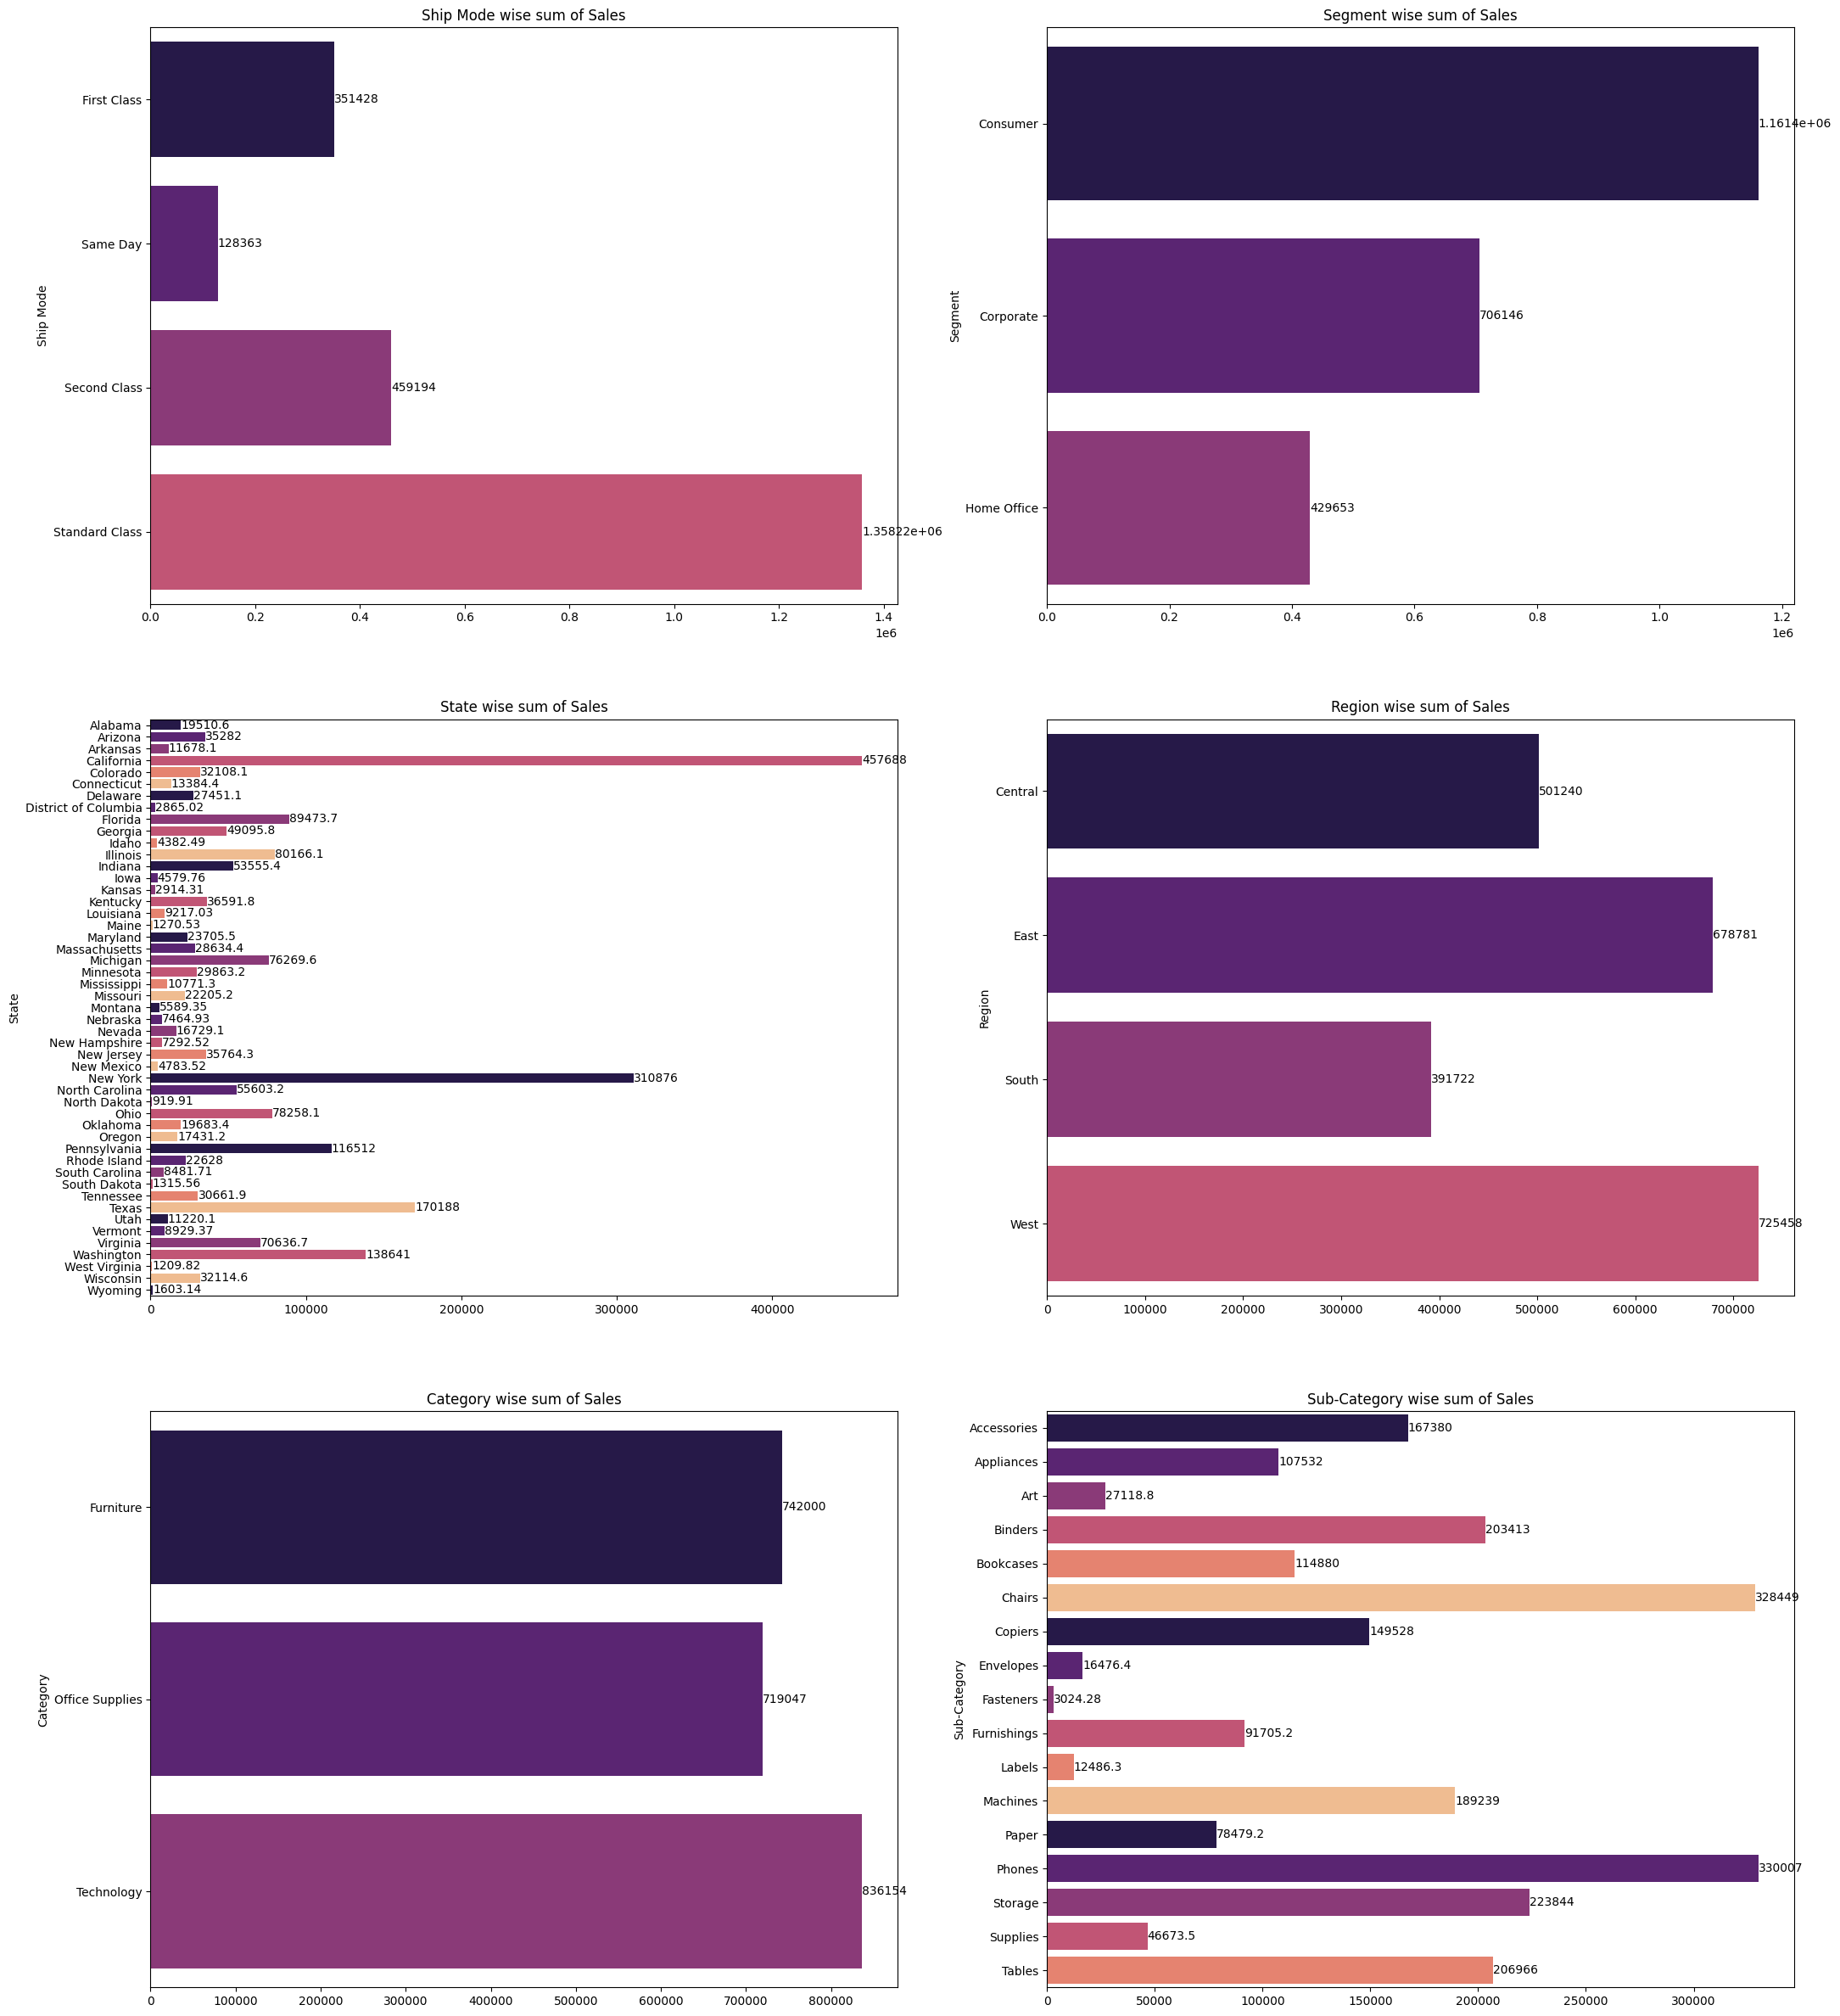

In [32]:
#Bivariate Analysis for Sales (Duplicate)
x=['Ship Mode','Segment', 'State','Region','Category', 'Sub-Category']
y=['Sales']

plt.figure(figsize=(25,30))
counter=1
for i in x:
  plt.subplot(3,2, counter)
  x_axis=df.groupby(i)['Sales'].sum().index
  y_axis=df.groupby(i)['Sales'].sum().values
  plt.title(f"{i} wise sum of Sales")
  ax =sns.barplot(y=x_axis, x=y_axis, palette=sns.color_palette('magma'))
  for value in ax.containers:
    plt.bar_label(value)
  counter+=1
plt.show()

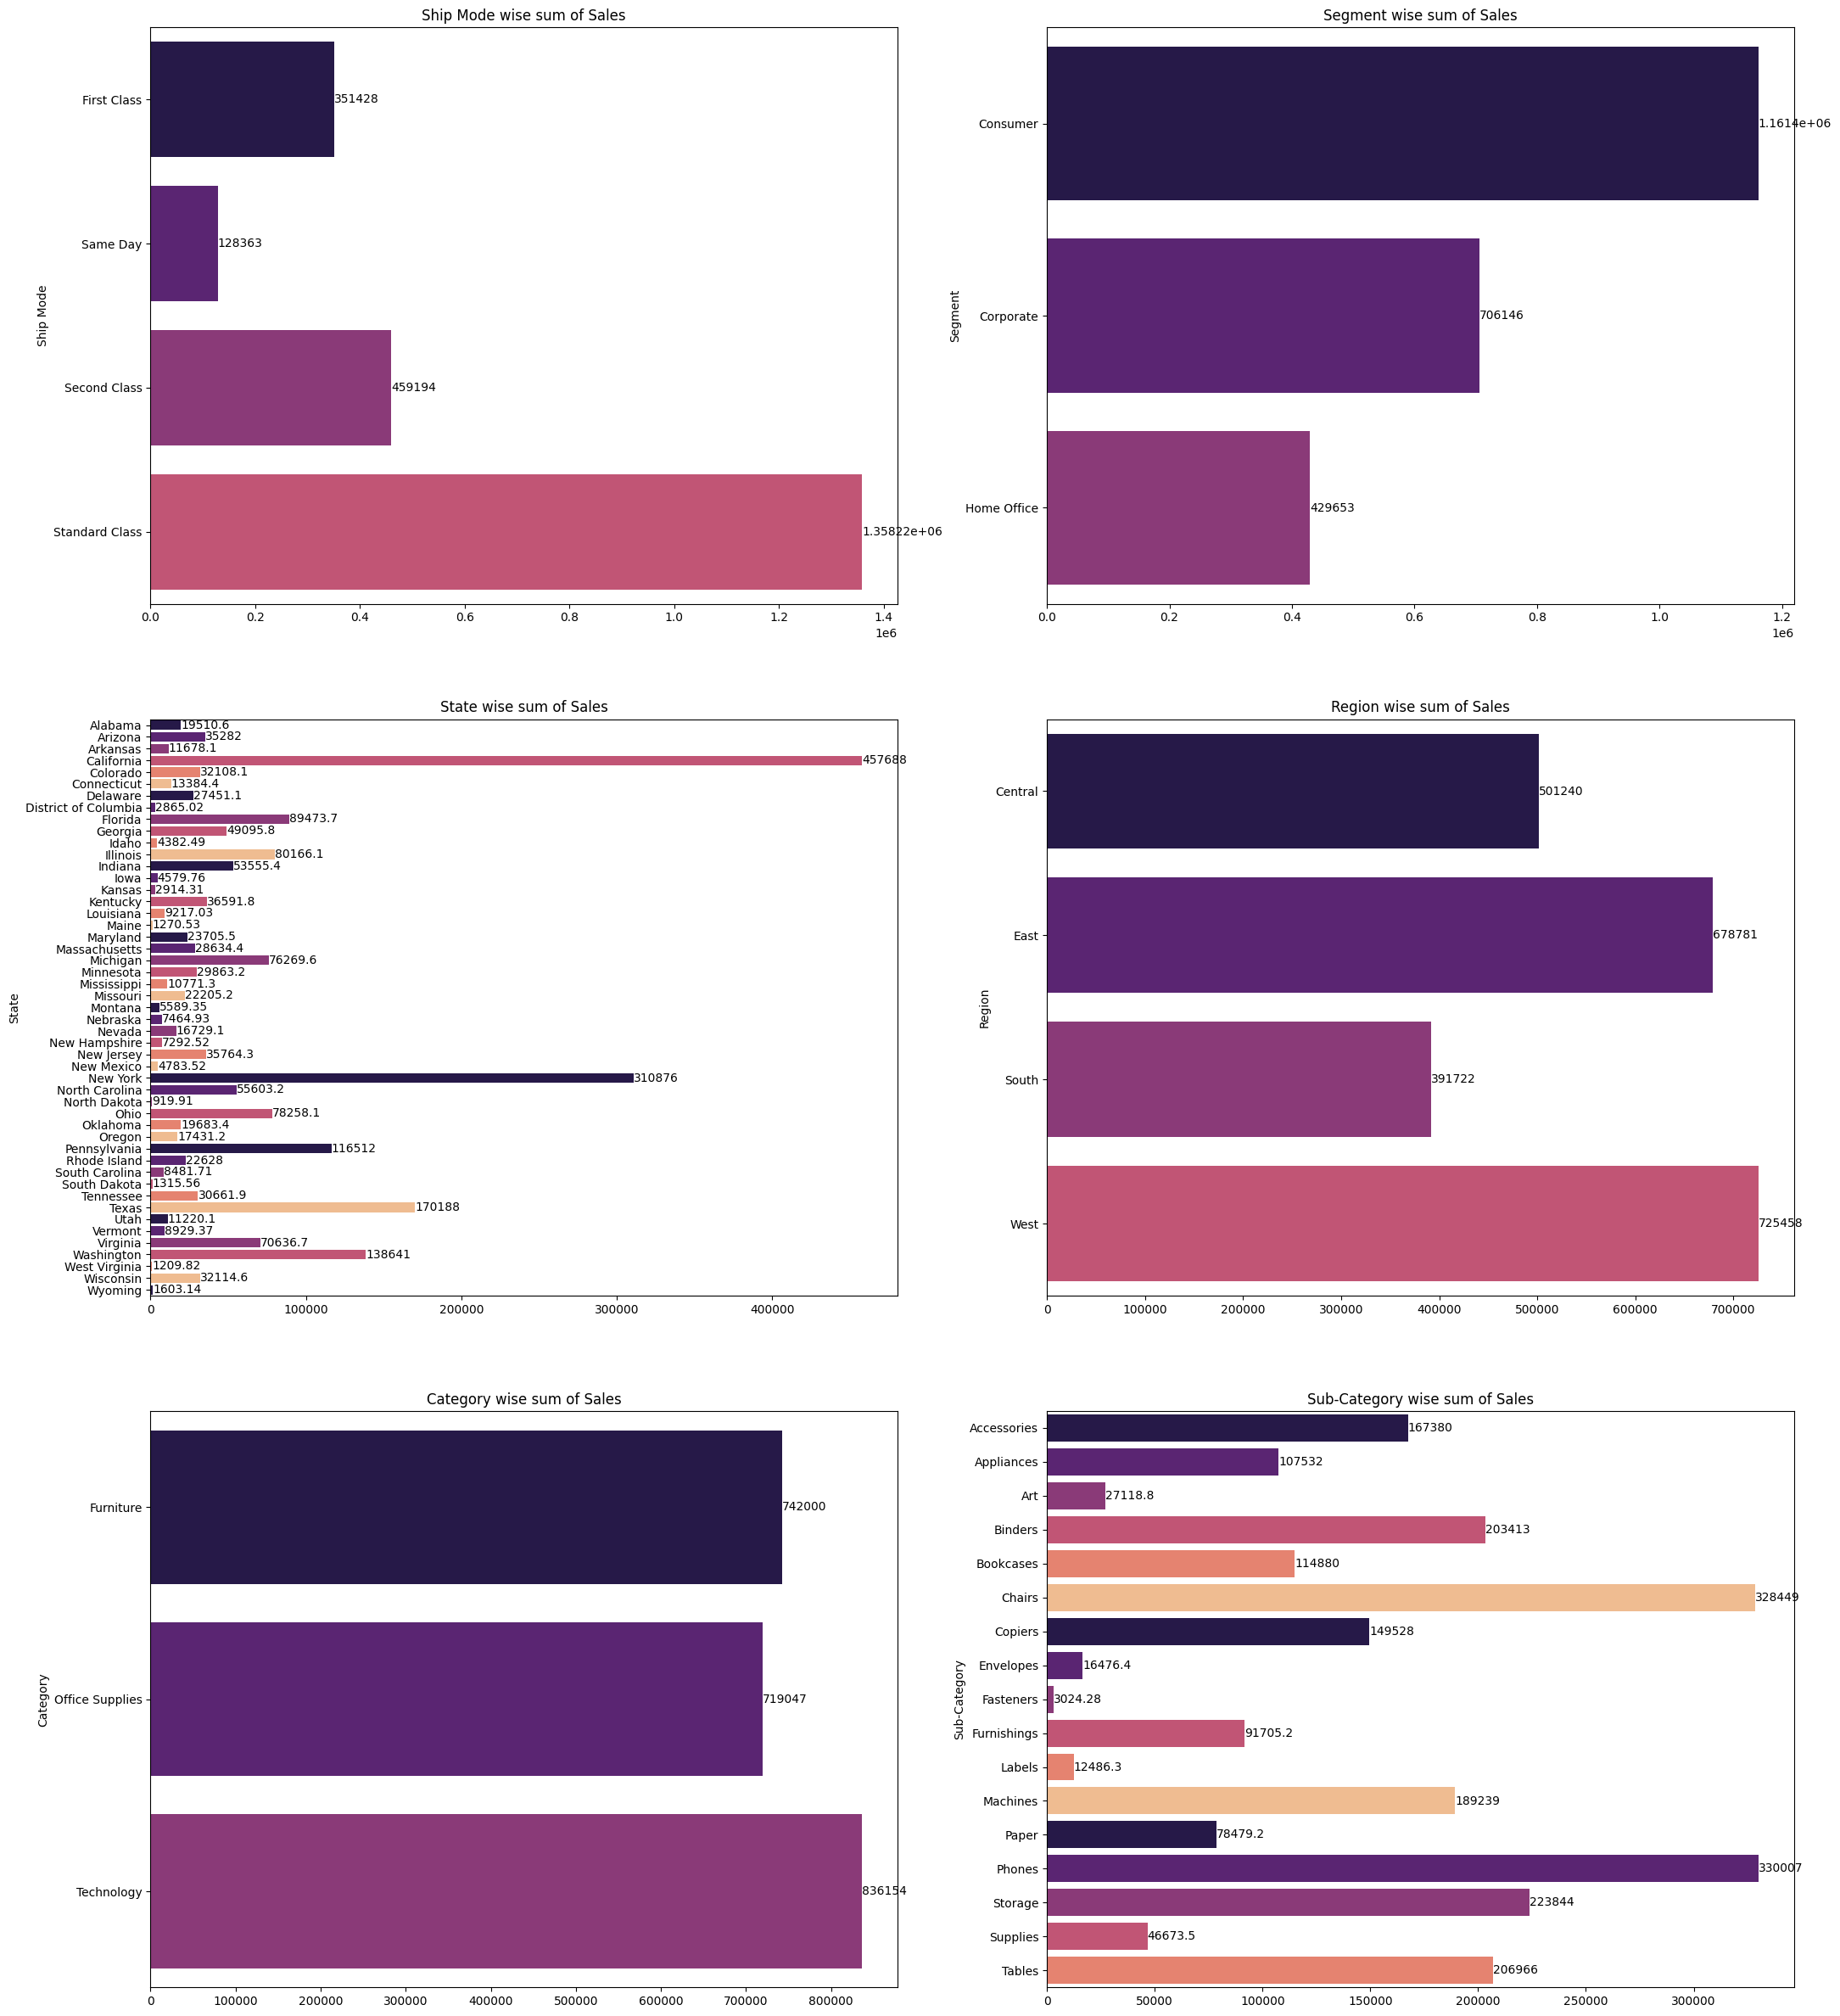

In [33]:
#Bivariate Analysis for Sales
x=['Ship Mode','Segment', 'State','Region','Category', 'Sub-Category']
y=['Sales']

plt.figure(figsize=(25,30))
counter=1
for i in x:
  for j in y:
    plt.subplot(3,2, counter)
    x_axis=df.groupby(i)[j].sum().index
    y_axis=df.groupby(i)[j].sum().values
    plt.title(f"{i} wise sum of {j}")
    ax =sns.barplot(y=x_axis, x=y_axis, palette=sns.color_palette('magma'))
    for value in ax.containers:
      plt.bar_label(value)
    counter+=1
plt.show()

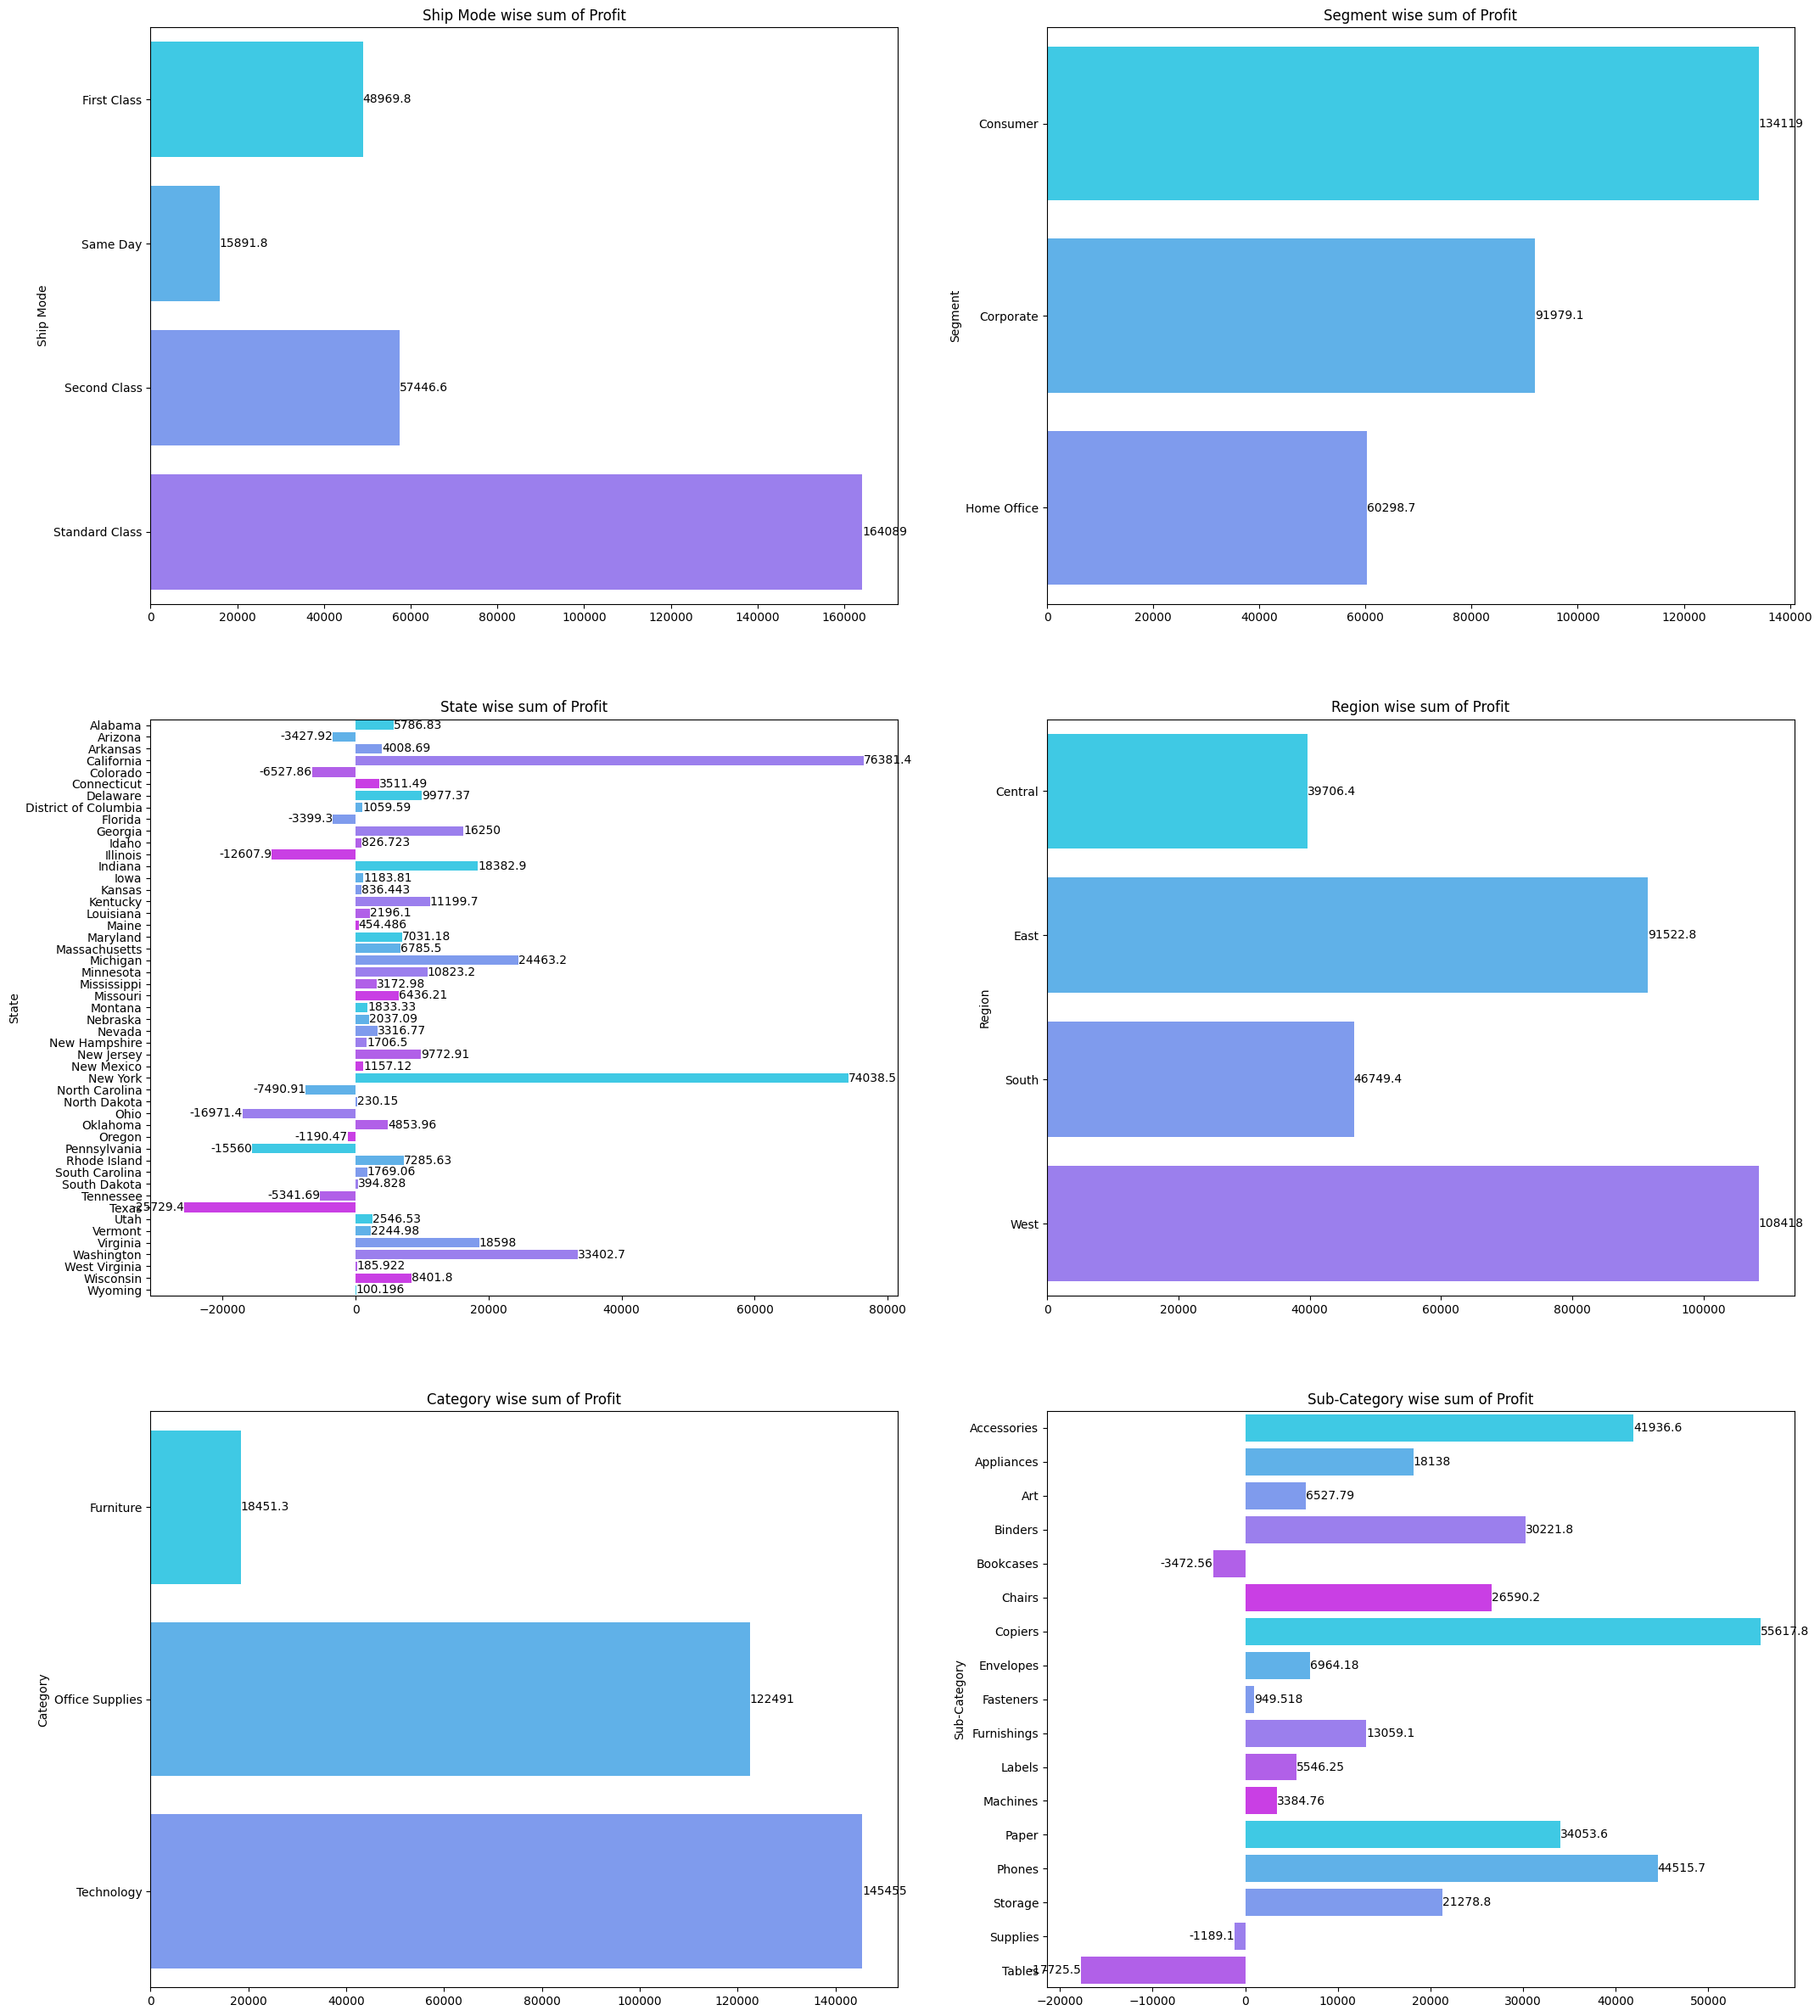

In [34]:
#Bivariate Analysis for Profit
x=['Ship Mode','Segment', 'State','Region','Category', 'Sub-Category']
y=['Profit']

plt.figure(figsize=(25,30))
counter=1
for i in x:
  for j in y:
    plt.subplot(3,2, counter)
    x_axis=df.groupby(i)[j].sum().index
    y_axis=df.groupby(i)[j].sum().values
    plt.title(f"{i} wise sum of {j}")
    ax =sns.barplot(y=x_axis, x=y_axis, palette=sns.color_palette('cool'))
    for value in ax.containers:
      plt.bar_label(value)
    counter+=1
plt.show()

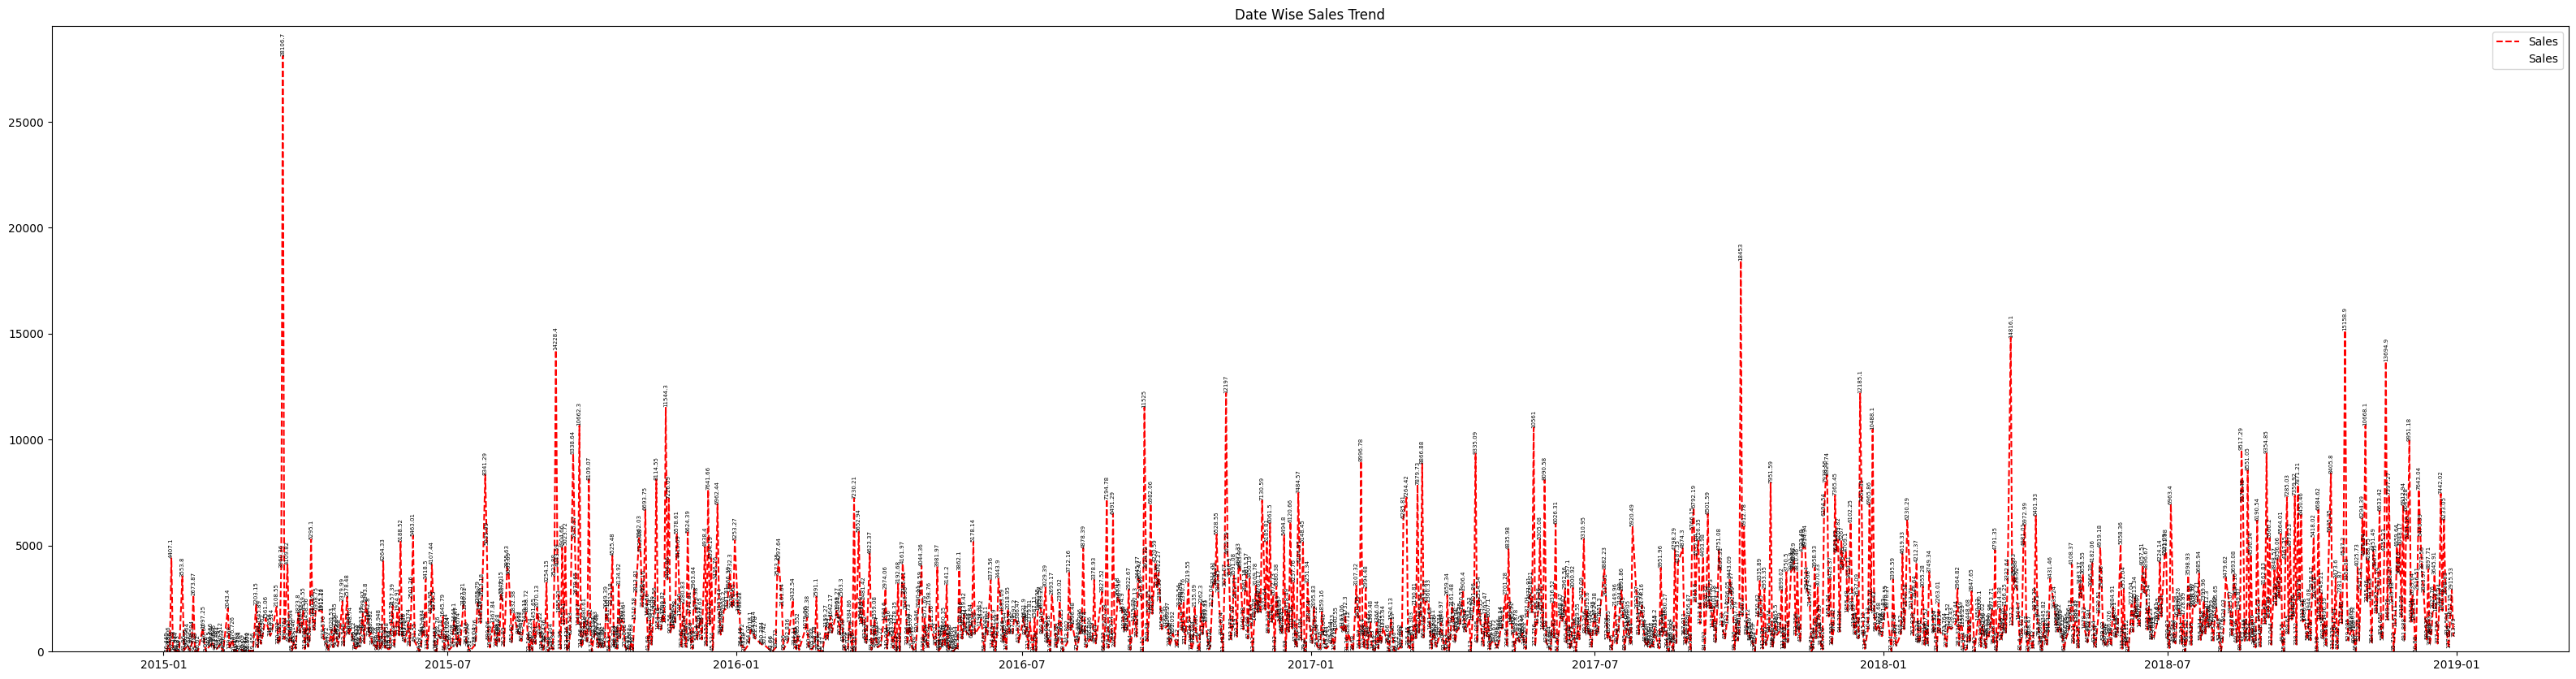

In [35]:
#Time Series Analysis
plt.figure(figsize=(40,10))
x=df.groupby('Order Date')['Sales'].sum().sort_index().index
y=df.groupby('Order Date')['Sales'].sum().sort_index().values
plt.title("Date Wise Sales Trend")
plt.plot(x,y,color='r', linestyle='--', label='Sales')
ax=plt.bar(x,y,color='r', linestyle='--', label='Sales', alpha=0)
plt.bar_label(ax, rotation=90, fontsize=5)
plt.legend()
plt.show()

In [36]:
df['Month']=df['Order Date'].dt.month_name()
df['Year']=df['Order Date'].dt.year
print('Done')

Done


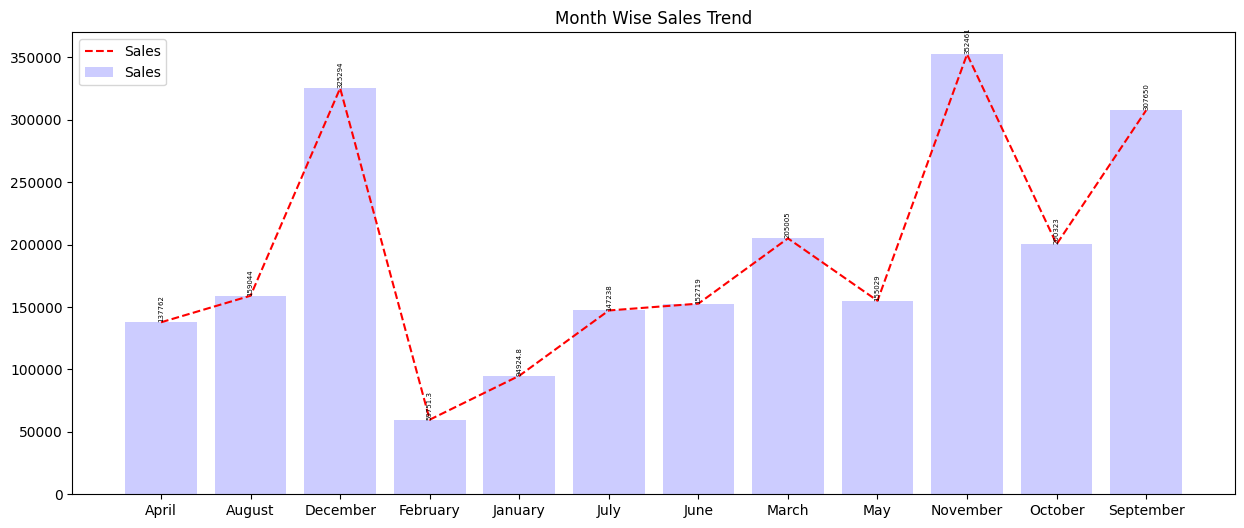

In [37]:
#Monthly Time Series Analysis
plt.figure(figsize=(15,6))
x=df.groupby('Month')['Sales'].sum().sort_index().index
y=df.groupby('Month')['Sales'].sum().sort_index().values
plt.title("Month Wise Sales Trend")
plt.plot(x,y,color='r', linestyle='--', label='Sales')
ax=plt.bar(x,y,color='b', label='Sales', alpha=0.2)
plt.bar_label(ax, rotation=90, fontsize=5)
plt.legend()
plt.show()

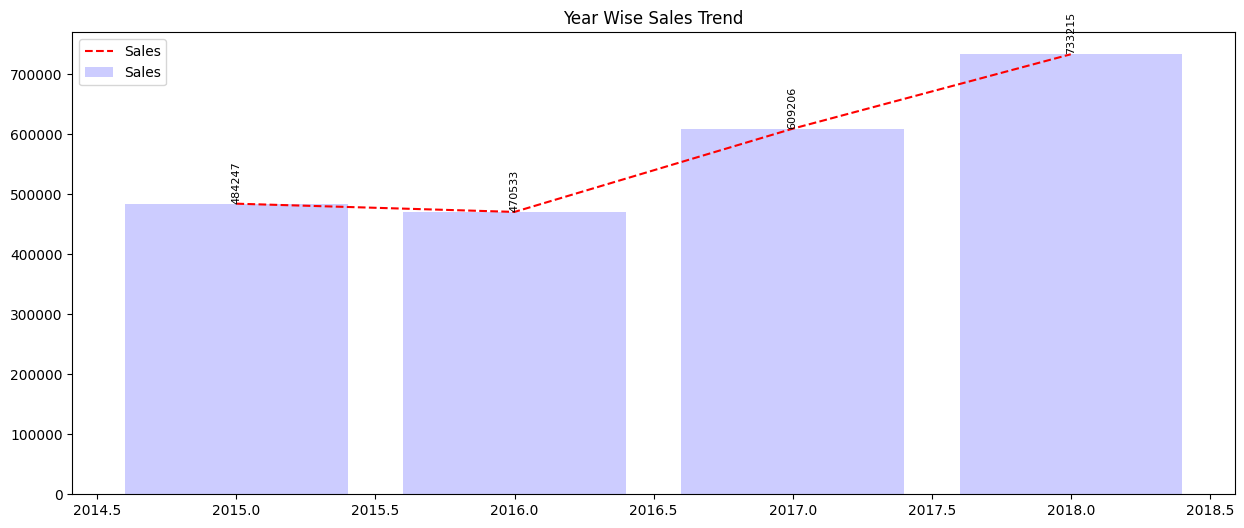

In [38]:
#Yearly Time Series Analysis
plt.figure(figsize=(15,6))
x=df.groupby('Year')['Sales'].sum().sort_index().index
y=df.groupby('Year')['Sales'].sum().sort_index().values
plt.title("Year Wise Sales Trend")
plt.plot(x,y,color='r', linestyle='--', label='Sales')
ax=plt.bar(x,y,color='b', label='Sales', alpha=0.2)
plt.bar_label(ax, rotation=90, fontsize=8)
plt.legend()
plt.show()

# Multivariate Analysis

In [39]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Month',
       'Year'],
      dtype='object')

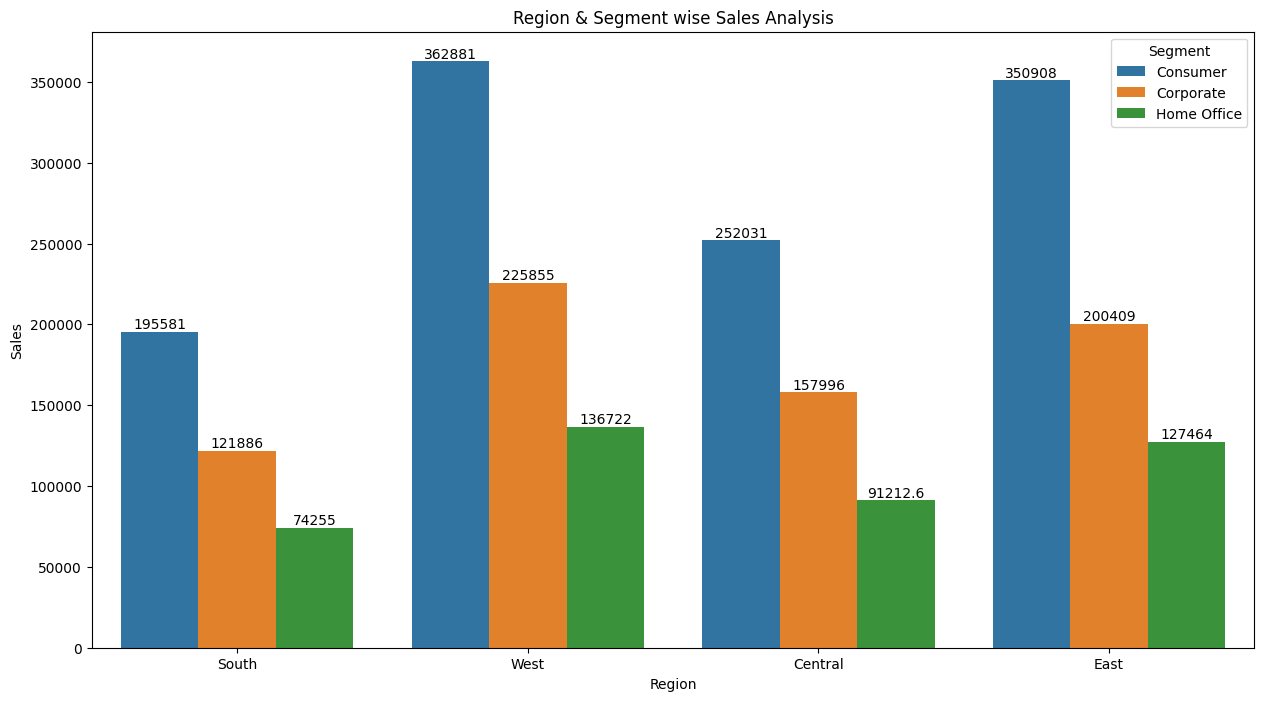

In [40]:
#Region & segment wise sales analysis
plt.figure(figsize=(15,8))
plt.title("Region & Segment wise Sales Analysis")
ax=sns.barplot(data=df, x='Region', y='Sales', hue='Segment', estimator='sum', errorbar=None)
for i in ax.containers:
  plt.bar_label(i)
plt.show()
#Errorbars

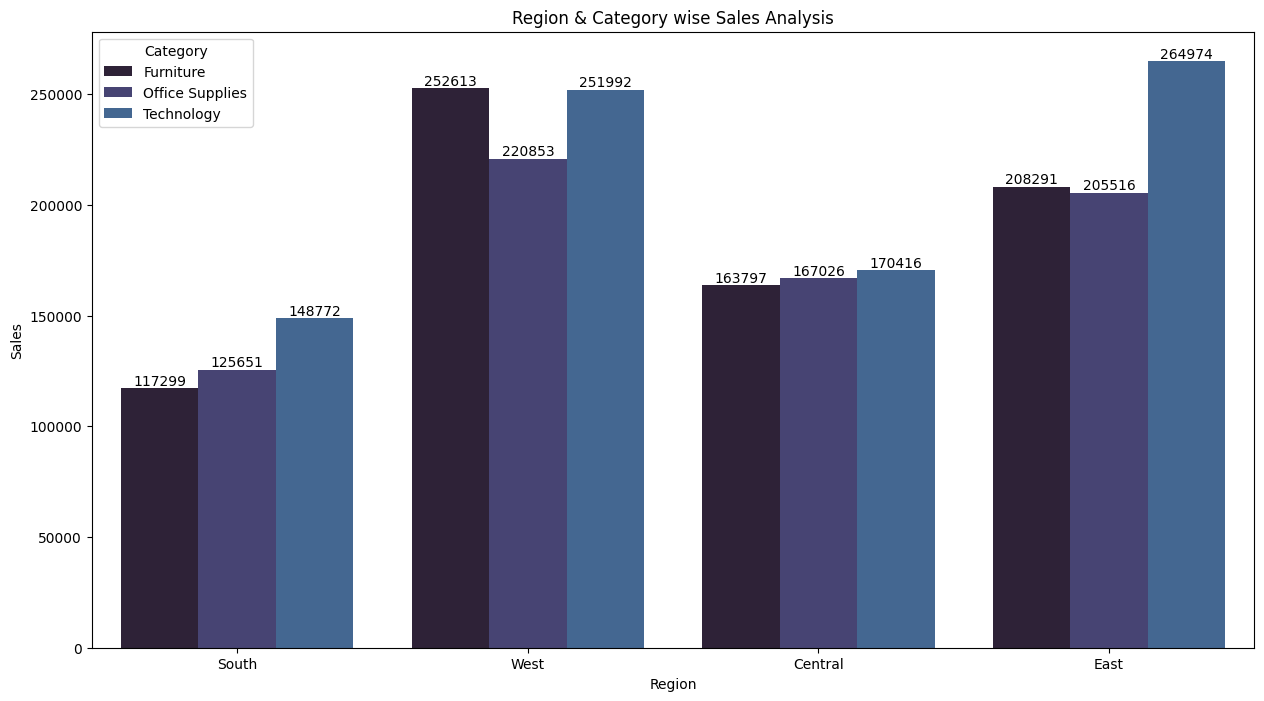

In [41]:
#Region & Category wise sales analysis
plt.figure(figsize=(15,8))
plt.title("Region & Category wise Sales Analysis")
ax=sns.barplot(data=df, x='Region', y='Sales', hue='Category', estimator='sum', palette=sns.color_palette('mako') , errorbar=None)
for i in ax.containers:
  plt.bar_label(i)
plt.show()

In [42]:
#Yearly & Monthly Sales Trend Analysis
year=df['Year'].unique()
year.sort()
print(year)

[2015 2016 2017 2018]


In [43]:
df_2015=df[df['Year']==2015]
df_2016=df[df['Year']==2016]
df_2017=df[df['Year']==2017]
df_2018=df[df['Year']==2018]

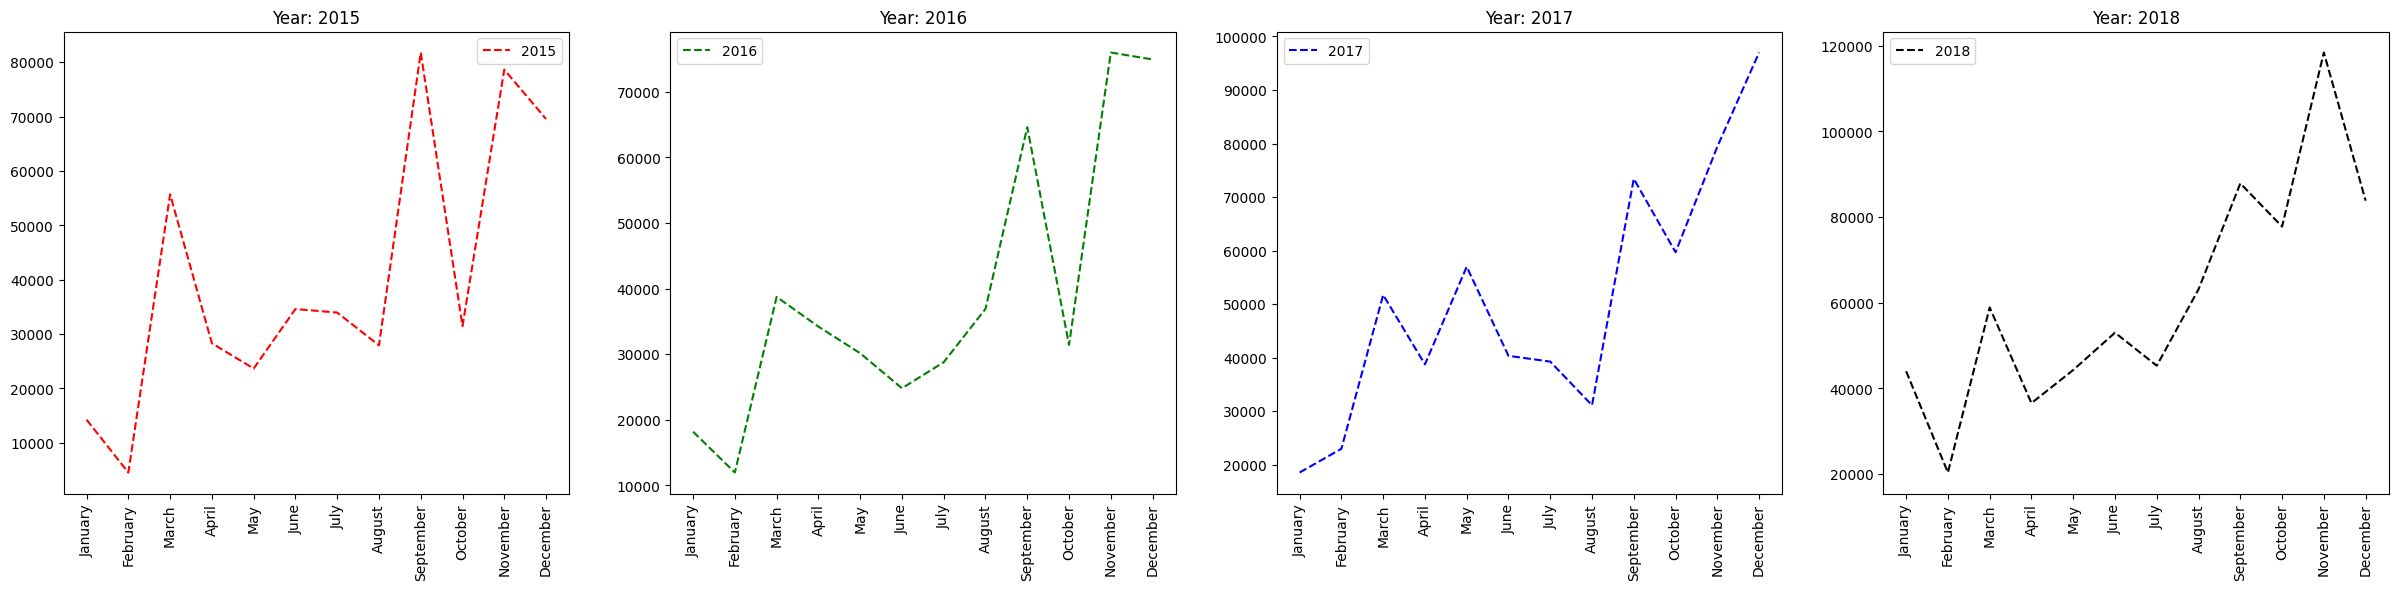

In [44]:
import calendar

plt.figure(figsize=(30,6))
month_sorted=list(calendar.month_name[1:])
year_df=[df_2015,df_2016,df_2017,df_2018]

color=['r','g','b','k']
for j,i in enumerate(year_df):
  i['Month']=pd.Categorical(i['Month'], categories=month_sorted, ordered=True)

  grouped_data=i.groupby('Month')['Sales'].sum()
  x=grouped_data.index
  y=grouped_data.values

  plt.subplot(1,4,j+1)
  plt.plot(x,y, linestyle='--', color=color[j],label=i['Year'].unique())
  plt.xticks(rotation=90)
  plt.legend()
  plt.title(f"Year: {i['Year'].unique()[0]}")
plt.show()

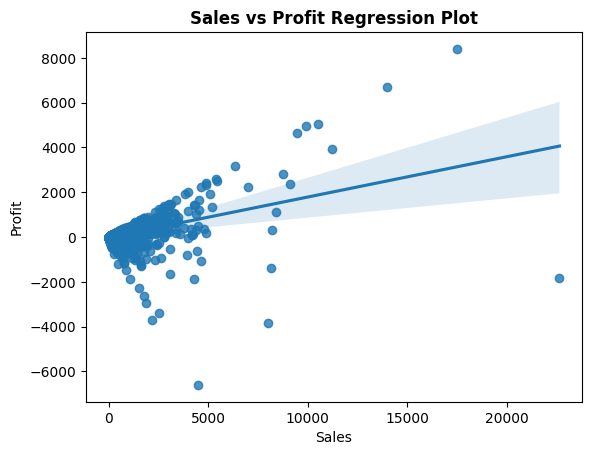

In [ ]:
#sales vs Profit Regression Plot to analyze trend
plt.title("Sales vs Profit Regression Plot", fontweight='bold')
sns.regplot(data=df, x='Sales', y='Profit')
plt.show()

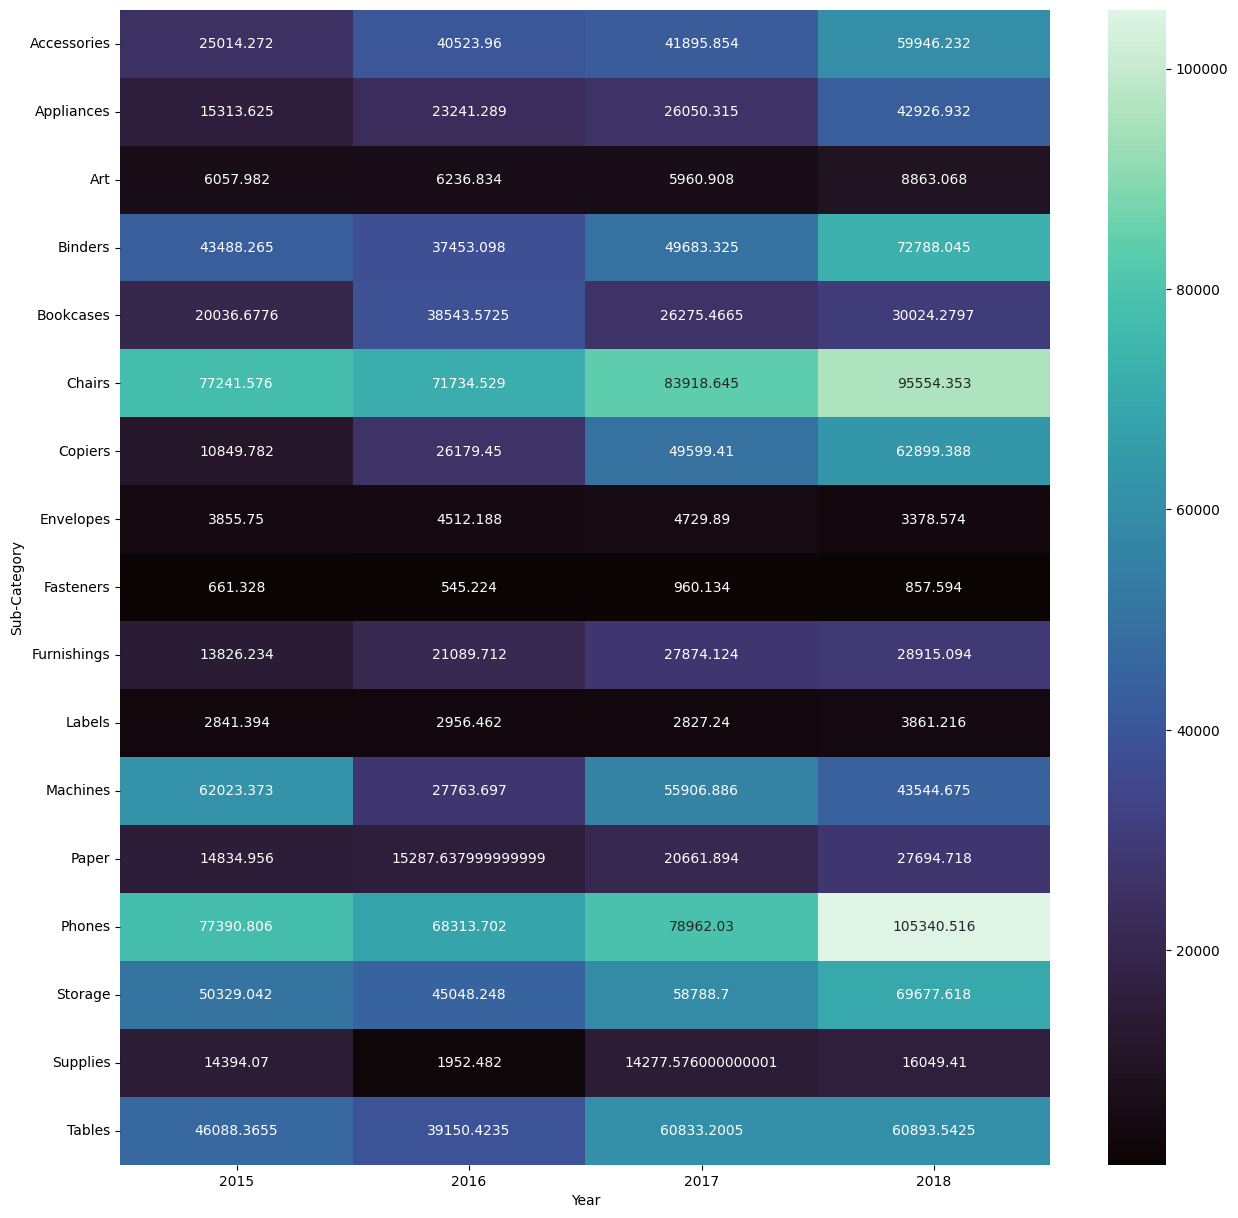

In [ ]:
plt.figure(figsize=(15,15))
pivot_data=df.pivot_table(values='Sales', index='Sub-Category', columns='Year', aggfunc='sum')

sns.heatmap(data=pivot_data, annot=True, cmap='mako', fmt="")
plt.show()

#Insights & Remark

#EDA perform by: Arpit
- Most of the transactions, around 75% stays under $210.

- Around 75% of the customers purchase less than 5 or 5 products. Most commonly people buy 2 or 3 product.

- In most of the sales, we get a profit of less then or $29.

- Record sales in a single day was recorded on 9 September 2017 with 38 order.

- Standard Class is preferred the most for shipping, used 5968 times.

- California brings the most orders, making the West region, most performing region.

-  Most orders come from Consumer segment.

- Office Supplies is the most popular category with 6026 items ordered.

-